# Cat Qubit Loss Function

This notebook defines a loss function for **online optimization of cat qubit stabilization**, structured to mirror the `pi_pulse_loss_func` pattern in `challenge/1-challenge.ipynb`.

**System:** Storage mode $a$ coupled to a lossy buffer $b$ via:
$$H/\hbar = g_2^* a^2 b^\dagger + g_2 (a^\dagger)^2 b - \epsilon_d b^\dagger - \epsilon_d^* b$$
$$L_b = \sqrt{\kappa_b}\, b, \quad L_a = \sqrt{\kappa_a}\, a$$

**Knobs (4 real parameters):** $x = [\text{Re}(g_2),\ \text{Im}(g_2),\ \text{Re}(\epsilon_d),\ \text{Im}(\epsilon_d)]$

**Objective:** Maximize both $T_X$ and $T_Z$ while achieving target bias $\eta = T_Z / T_X$.

**Proxy strategy (measurement-efficient):**
- $T_X$ proxy — start from $|{+x_L}\rangle = (|\alpha\rangle + |-\alpha\rangle)/\sqrt{2}$, measure parity $\langle P \rangle$ at fixed short time
- $T_Z$ proxy — start from $|{+z_L}\rangle = |\alpha\rangle$, measure $\langle Z_L \rangle$ at fixed longer time

Both proxies avoid exponential-decay fitting, keeping per-call cost to two `mesolve` runs.

In [12]:
import dynamiqs as dq
import jax.numpy as jnp
from jax import vmap, jit
from matplotlib import pyplot as plt
from cmaes import SepCMA

## Fixed System Parameters

These are hardware constants — **not** tunable by the online optimizer.

In [13]:
# ── Hilbert space truncation ──────────────────────────────────────────────────
# NA: number of Fock states kept for the storage mode.
#     Must be large enough to contain |alpha|^2 mean photons.
#     With alpha ~ 2, <n> ~ 4, so NA=15 gives plenty of headroom.
# NB: buffer mode truncation. Buffer stays near vacuum (fast decay),
#     so NB=5 is sufficient.
NA = 15
NB = 5

# ── Hardware loss rates [MHz] ─────────────────────────────────────────────────
# KAPPA_B: buffer decay rate. Intentionally large (10 MHz) so the buffer
#          can be adiabatically eliminated, leaving effective 2-photon
#          dissipation on the storage. The condition kappa_b >> |g2| must hold.
# KAPPA_A: single-photon loss of the storage resonator (1 MHz).
#          This is the dominant error channel — it drives both phase flips
#          (fast, ~1/kappa_a) and, indirectly, bit flips (slow, exponential in alpha^2).
KAPPA_B = 10.0
KAPPA_A = 1.0

# ── Proxy evaluation times [us] ──────────────────────────────────────────────
# Instead of running a full exponential-decay fit (which needs many time points
# and is expensive), we measure the state at a single snapshot time.
#
# T_X_EVAL: chosen near the phase-flip timescale T_X ~ 1/kappa_a ~ 1 us.
#           At this time, a short-lived state will have decayed significantly
#           while a long-lived one remains close to its initial value.
# T_Z_EVAL: chosen much longer (50 us) because bit flips are exponentially
#           suppressed and T_Z >> T_X for a well-stabilized cat.
T_X_EVAL = 1.0
T_Z_EVAL = 50.0

# ── Loss weights ─────────────────────────────────────────────────────────────
# These control the trade-off between the three objectives.
# Increase LAMBDA_X / LAMBDA_Z to prioritize raw lifetime.
# Increase LAMBDA_BIAS to strictly enforce the target bias ratio.
LAMBDA_X    = 1.0    # weight on the T_X proxy reward
LAMBDA_Z    = 0.5    # weight on the T_Z proxy reward (lower: T_Z is harder to improve)
LAMBDA_BIAS = 0.1    # penalty weight for deviating from ETA_TARGET

# Target bias: eta = T_Z / T_X.
# Cat qubits are biased — we want T_Z >> T_X to exploit the noise asymmetry.
# A value of 50 means T_Z should be 50x longer than T_X.
ETA_TARGET  = 50.0
# ── Alpha regularization ────────────────────────────────────────────
# Without this, the optimizer drives eps_d to its upper bound indefinitely,
# because T_Z grows exponentially in alpha^2 and the loss never stops improving.
#
# This penalty adds a cost for alpha deviating from ALPHA_TARGET, forcing the
# optimizer to settle at a specific operating point rather than hitting the bound.
#
# Physical reasons to keep alpha bounded:
#   1. Adiabatic elimination (kappa_b >> |g2|) breaks down at very large drives.
#   2. NA=15 only fits states with mean photon number << 15.
#      alpha=2 -> <n>=4 (fine), alpha=5 -> <n>=25 (Hilbert space too small).
#   3. Large drives cause unwanted nonlinear effects in real hardware.
#
# To target a larger cat, increase both ALPHA_TARGET and NA together.
ALPHA_TARGET = 2.0   # desired cat size (mean photon number = alpha^2 = 4)
LAMBDA_ALPHA = 0.5   # penalty weight — raise to enforce more strictly


## Loss Function

Structured analogously to `pi_pulse_loss_func` in the challenge notebook:
- Takes a 1D array of knob values
- Returns a scalar loss (lower = better)
- JIT-compiled and vmappable for batched CMA-ES evaluation

In [14]:
@jit
def cat_loss_func(x):
    """
    Cat qubit stabilization loss function.

    Parameters
    ----------
    x : array, shape (4,)
        [Re(g2), Im(g2), Re(eps_d), Im(eps_d)]
        CMA-ES operates over real vectors, so each complex parameter
        is split into two real components.

    Returns
    -------
    float
        Scalar loss. Minimize this to maximize T_X, T_Z and hit target bias.
    """

    # ── Unpack knobs ──────────────────────────────────────────────────────────
    # g_2: two-photon coupling between storage (a^2) and buffer (b).
    #      Its magnitude controls the effective 2-photon dissipation rate kappa_2.
    #      Its phase shifts the orientation of the cat blobs in phase space.
    # eps_d: amplitude of the coherent drive applied to the buffer.
    #        Together with g_2 it sets the cat size alpha.
    g_2   = x[0] + 1j * x[1]
    eps_d = x[2] + 1j * x[3]

    # ── Build operators ───────────────────────────────────────────────────────
    # dq.tensor pads each operator with an identity on the other mode,
    # so 'a' acts on storage only and 'b' acts on buffer only.
    a = dq.tensor(dq.destroy(NA), dq.eye(NB))   # storage annihilation: acts on NA x NB space
    b = dq.tensor(dq.eye(NA), dq.destroy(NB))   # buffer annihilation:  acts on NA x NB space

    # Two-mode Hamiltonian (see challenge notebook cell 33):
    #   conj(g2) * a^2 b†  — absorbs 2 storage photons, emits 1 buffer photon
    #   g2 * (a†)^2 b      — reverse process
    #   -eps_d * b†        — coherent drive pumps buffer
    #   -conj(eps_d) * b   — Hermitian conjugate of the drive term
    H = (jnp.conj(g_2) * a @ a @ b.dag()
         + g_2 * a.dag() @ a.dag() @ b
         - eps_d * b.dag()
         - jnp.conj(eps_d) * b)

    # Jump operators for the Lindblad master equation:
    #   L_b: fast buffer decay — removes buffer excitations at rate kappa_b
    #   L_a: single-photon storage loss — the main error channel
    jump_ops = [jnp.sqrt(KAPPA_B) * b,
                jnp.sqrt(KAPPA_A) * a]

    # ── Derive cat size from adiabatic elimination ────────────────────────────
    # When kappa_b >> |g2|, the buffer can be traced out. The resulting
    # effective dynamics on the storage mode have:
    #   kappa_2 = 4|g2|^2 / kappa_b   (effective 2-photon dissipation rate)
    #   eps_2   = 2*g2*eps_d / kappa_b (effective 2-photon drive amplitude)
    # The steady-state cat size is then alpha = sqrt(eps_2 / kappa_2 - kappa_a/(4*kappa_2)).
    # We need alpha_est to build the logical basis states below.
    kappa_2   = 4.0 * jnp.abs(g_2)**2 / KAPPA_B
    eps_2     = 2.0 * g_2 * eps_d / KAPPA_B
    alpha_est = jnp.sqrt(jnp.abs(jnp.real(2.0 / kappa_2 * (eps_2 - KAPPA_A / 4.0))))

    # ── Logical basis states ──────────────────────────────────────────────────
    # The cat qubit encodes logical |0> and |1> in two coherent states
    # |+alpha> and |-alpha> of the storage oscillator.
    # We tensor with the buffer vacuum |0>_b because the buffer starts at rest.
    cat_pos = dq.tensor(dq.coherent(NA,  alpha_est), dq.fock(NB, 0))  # |+z_L> = |+alpha> x |0>_b
    cat_neg = dq.tensor(dq.coherent(NA, -alpha_est), dq.fock(NB, 0))  # |-z_L> = |-alpha> x |0>_b

    # |+x_L> is the equal superposition of the two coherent states (even cat state).
    # Phase flips (driven by kappa_a) decay this toward the mixed state.
    psi_x = (cat_pos + cat_neg) / jnp.sqrt(2)

    # ── Observables ──────────────────────────────────────────────────────────
    # Parity operator P = exp(i*pi*a†a):
    #   - Eigenvalue +1 for even photon number states (including even cat)
    #   - Eigenvalue -1 for odd photon number states (including odd cat)
    #   - Acts as the logical X operator on the cat qubit
    #   - Key advantage: does NOT require knowing alpha — directly measurable
    #     in experiment via Wigner function sampling.
    parity = (1j * jnp.pi * (a.dag() @ a)).expm()

    # Logical Z observable: Z_L = |+z_L><+z_L| - |-z_L><-z_L|
    #   - +1 when the state is in |+alpha> (logical |0>)
    #   - -1 when the state is in |-alpha> (logical |1>)
    #   - Requires alpha_est to construct — less robust than parity
    sz_storage = (dq.coherent(NA,  alpha_est) @ dq.coherent(NA,  alpha_est).dag()
                - dq.coherent(NA, -alpha_est) @ dq.coherent(NA, -alpha_est).dag())
    z_logical  = dq.tensor(sz_storage, dq.eye(NB))  # extend to full storage x buffer space

    # ── T_X proxy: phase-flip lifetime ───────────────────────────────────────
    # Initial state: |+x_L> (even cat superposition, <parity>=+1 at t=0)
    # Under single-photon loss, the parity decays as exp(-kappa_a * t).
    # A higher <parity> at T_X_EVAL means slower phase flips, i.e., longer T_X.
    # We only save two time points [0, T_X_EVAL] — no full curve needed.
    res_x = dq.mesolve(
        H, jump_ops, psi_x,
        jnp.array([0.0, T_X_EVAL]),  # only need the final time point
        exp_ops=[parity],
        options=dq.Options(progress_meter=False)
    )
    # res_x.expects shape: [n_obs, n_times] -> take observable 0, final time
    sx_val = res_x.expects[0, -1].real

    # ── T_Z proxy: bit-flip lifetime ─────────────────────────────────────────
    # Initial state: |+z_L> = |+alpha> (<Z_L>=+1 at t=0)
    # Bit flips (|+alpha> -> |-alpha>) are exponentially suppressed in alpha^2,
    # so we probe at a much longer time T_Z_EVAL.
    # A higher <Z_L> at T_Z_EVAL means fewer bit flips, i.e., longer T_Z.
    res_z = dq.mesolve(
        H, jump_ops, cat_pos,
        jnp.array([0.0, T_Z_EVAL]),  # only need the final time point
        exp_ops=[z_logical],
        options=dq.Options(progress_meter=False)
    )
    # res_z.expects shape: [n_obs, n_times] -> take observable 0, final time
    sz_val = res_z.expects[0, -1].real

    # ── Bias proxy and penalty ────────────────────────────────────────────────
    # True bias would be eta = T_Z / T_X, requiring two full exponential fits.
    # Proxy: sz_val decays slowly (long T_Z -> sz near 1) while sx_val decays
    # fast (short T_X -> sx near 0). Their ratio is a rough stand-in for eta.
    # The epsilon (1e-6) prevents division by zero if parity collapses.
    bias_proxy   = sz_val / (jnp.abs(sx_val) + 1e-6)
    # Squared deviation from target: zero when bias_proxy == ETA_TARGET
    bias_penalty = (bias_proxy - ETA_TARGET)**2

    # ── Alpha penalty ─────────────────────────────────────────────────────
    # alpha_est was already computed above from g_2 and eps_d.
    # We penalise (alpha_est - ALPHA_TARGET)^2.
    # This creates a "bowl" in the loss landscape centred on ALPHA_TARGET,
    # so the optimizer cannot keep lowering loss by just increasing eps_d:
    # any gain from larger T_Z is eventually outweighed by this growing penalty.
    alpha_penalty = (alpha_est - ALPHA_TARGET)**2

    # ── Combined loss ─────────────────────────────────────────────────────
    # Four terms, each with an independent weight:
    #   -LAMBDA_X * sx_val      : reward for long T_X (sx close to +1 is good)
    #   -LAMBDA_Z * sz_val      : reward for long T_Z (sz close to +1 is good)
    #   +LAMBDA_BIAS * ...      : penalty for wrong bias ratio
    #   +LAMBDA_ALPHA * ...     : penalty for alpha != ALPHA_TARGET
    #                             this is what stops Re(eps_d) running to the bound
    loss = (-LAMBDA_X * sx_val
            - LAMBDA_Z * sz_val
            + LAMBDA_BIAS  * bias_penalty
            + LAMBDA_ALPHA * alpha_penalty)
    return loss


# vmap maps cat_loss_func over a batch of parameter vectors (one per CMA-ES candidate).
# jit compiles the entire batched function to XLA, so the whole population is
# evaluated in a single GPU/CPU kernel — same pattern as batched_pi_pulse_loss_func
# in the challenge notebook.
batched_cat_loss_func = jit(vmap(cat_loss_func))

## Sanity Check

Evaluate at the nominal parameters used throughout the challenge notebook
($g_2 = 1$, $\epsilon_d = 4$, both real).

In [15]:
# x = [Re(g2), Im(g2), Re(eps_d), Im(eps_d)]
# Nominal: the values used in challenge cells 33-41 (g2=1, eps_d=4, both real)
x_nominal = jnp.array([1.0, 0.0, 4.0, 0.0])

# Weak drive: small g2 and eps_d -> tiny alpha -> poor protection
# Expect this to give a higher (worse) loss than nominal
x_bad = jnp.array([0.1, 0.0, 1.0, 0.0])

print("Loss at nominal params: ", cat_loss_func(x_nominal))
print("Loss at weak params:    ", cat_loss_func(x_bad))

# Batched evaluation — both candidates in one JIT call
xs = jnp.stack([x_nominal, x_bad])
print("Batched losses:         ", batched_cat_loss_func(xs))

C:\Users\Luis Mendez\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\equinox\_module\_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Loss at nominal params:  194.63017
Loss at weak params:     249.99715
Batched losses:          [194.63017 249.99715]


## CMA-ES Optimization

Same CMA-ES loop structure as in `challenge/1-challenge.ipynb`, now optimizing the four cat qubit knobs.

In [16]:
BATCH_SIZE = 12   # CMA-ES population size (number of candidates per epoch)
N_EPOCHS   = 60   # total number of optimization epochs

# ── CMA-ES setup ─────────────────────────────────────────────────────────────
# mean0: starting point for the search distribution.
#        We start near the nominal operating point from the challenge notebook.
# sigma0: initial exploration scale (std dev of the search distribution).
#         0.3 lets the optimizer explore a reasonable neighbourhood before tightening.
mean0  = jnp.array([1.0, 0.0, 4.0, 0.0])
sigma0 = 0.3

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    # Hard bounds on each knob — prevents unphysical or numerically unstable regimes
    bounds=jnp.array([
        [0.1,  5.0],   # Re(g2): must be positive for stabilization; cap at 5 MHz
        [-2.0, 2.0],   # Im(g2): phase of the coupling
        [0.5, 10.0],   # Re(eps_d): buffer drive amplitude; must be positive
        [-2.0, 2.0],   # Im(eps_d): phase of the buffer drive
    ]),
    population_size=BATCH_SIZE,
    seed=0,            # fixed seed for reproducibility
)

# ── Logging ───────────────────────────────────────────────────────────────────
mean_history     = []   # optimizer mean (best estimate) at each epoch
loss_history     = []   # mean loss over the population at each epoch
loss_std_history = []   # std of losses (measures population spread / convergence)

# ── Training loop ────────────────────────────────────────────────────────────
for epoch in range(N_EPOCHS):

    # 1. Sample BATCH_SIZE candidate parameter vectors from the current
    #    Gaussian search distribution N(mean, sigma^2 * C)
    xs = jnp.array([optimizer.ask() for _ in range(optimizer.population_size)])

    # 2. Evaluate all candidates in a single batched JIT call
    losses = batched_cat_loss_func(xs)

    # 3. Tell CMA-ES the (solution, loss) pairs so it can update its distribution.
    #    CMA-ES expects the list sorted by ascending loss (best = lowest first).
    solutions = [(xs[i], float(losses[i])) for i in range(len(xs))]
    solutions.sort(key=lambda sv: sv[1])
    optimizer.tell(solutions)

    # 4. Log statistics for plotting
    mean_history.append(optimizer.mean.copy())        # current best-estimate params
    loss_history.append(float(losses.mean()))          # average loss this epoch
    loss_std_history.append(float(losses.std()))       # spread of losses

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | mean loss {loss_history[-1]:.4f} | mean params {optimizer.mean}")

# Convert to JAX arrays for easier slicing during plotting
mean_history     = jnp.array(mean_history)
loss_history     = jnp.array(loss_history)
loss_std_history = jnp.array(loss_std_history)

Epoch   0 | mean loss 223.5179 | mean params [1.2187797  0.03573306 4.1241827  0.28811848]
Epoch  10 | mean loss 94.2274 | mean params [ 0.7690811  -0.14828506  5.103642    1.1916376 ]
Epoch  20 | mean loss 11.8710 | mean params [ 0.95168555 -0.36336207  5.0933123   1.3083023 ]
Epoch  30 | mean loss 1.2258 | mean params [ 1.0169909 -0.4120211  5.1727734  1.5778731]
Epoch  40 | mean loss -0.1053 | mean params [ 1.0036209  -0.38464284  5.112199    1.6057942 ]
Epoch  50 | mean loss -0.4003 | mean params [ 0.99678534 -0.37151003  5.100102    1.5813341 ]


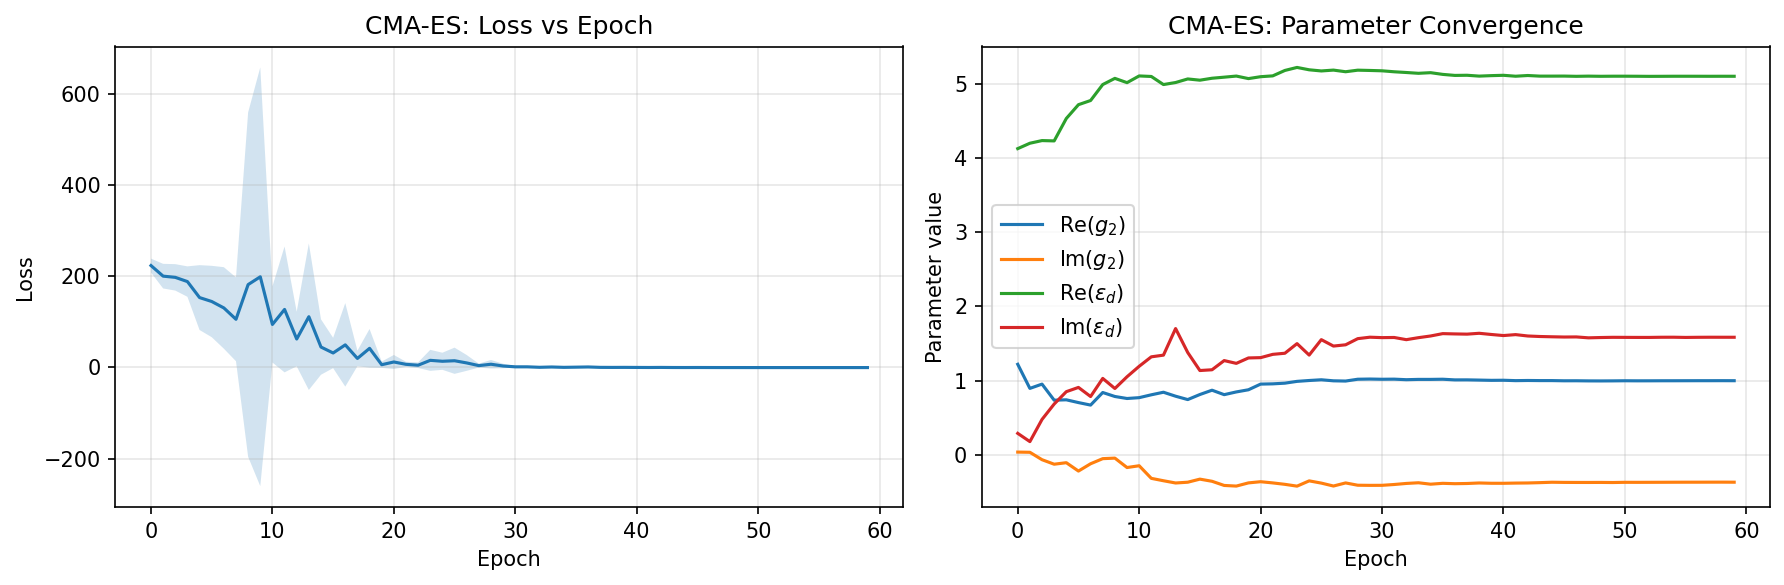

In [17]:
epochs = jnp.arange(N_EPOCHS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# ── Plot 1: Loss vs epoch ─────────────────────────────────────────────────────
# A downward trend means the optimizer is finding better parameter settings.
# The shaded band shows the spread across the population — it should narrow
# as CMA-ES converges and sigma shrinks.
ax = axes[0]
ax.plot(epochs, loss_history, label="Mean loss")
ax.fill_between(epochs,
                loss_history - loss_std_history,
                loss_history + loss_std_history,
                alpha=0.2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("CMA-ES: Loss vs Epoch")
ax.grid(True, alpha=0.3)

# ── Plot 2: Parameter convergence ────────────────────────────────────────────
# Each line is one of the four knobs. They should plateau as the optimizer
# finds the optimal operating point. Im(g2) and Im(eps_d) converging near 0
# would suggest the optimal drive phases are real-valued.
ax = axes[1]
labels = [r"$\mathrm{Re}(g_2)$", r"$\mathrm{Im}(g_2)$",
          r"$\mathrm{Re}(\epsilon_d)$", r"$\mathrm{Im}(\epsilon_d)$"]
for k, lbl in enumerate(labels):
    ax.plot(epochs, mean_history[:, k], label=lbl)
ax.set_xlabel("Epoch")
ax.set_ylabel("Parameter value")
ax.set_title("CMA-ES: Parameter Convergence")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()